In [3]:
!git clone https://github.com/sakanaowo/DragonFruit

Cloning into 'DragonFruit'...
remote: Enumerating objects: 4647, done.
remote: Counting objects: 100% (41/41), done.
remote: Compressing objects: 100% (23/23), done.
remote: Total 4647 (delta 19), reused 31 (delta 17), pack-reused 4606 (from 2)
Receiving objects: 100% (4647/4647), 1.57 GiB | 47.18 MiB/s, done.
Resolving deltas: 100% (632/632), done.
Updating files: 100% (8908/8908), done.


In [4]:
%cd DragonFruit

/kaggle/working/DragonFruit


In [42]:
!git pull


remote: Enumerating objects: 7, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 4 (delta 3), reused 4 (delta 3), pack-reused 0 (from 0)
Unpacking objects: 100% (4/4), 613 bytes | 613.00 KiB/s, done.
From https://github.com/sakanaowo/DragonFruit
   e6b9809..1a3f40b  dev        -> origin/dev
Already up to date.


In [7]:
!git checkout dev

Branch 'dev' set up to track remote branch 'dev' from 'origin'.
Switched to a new branch 'dev'


In [20]:
import sys
sys.path.append('/kaggle/working/DragonFruit')


In [44]:
!ls

config.yaml  models  outputs	requirements.txt  src	   utils
data	     notes   README.md	Sorted_dataset	  temp.py


In [45]:
!cat src/dataset.py


import numpy as np
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, WeightedRandomSampler
from utils.transform import train_transform, val_test_transform


def get_dataloaders(train_dir, val_dir, test_dir, batch_size, num_workers):
    train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
    val_dataset = datasets.ImageFolder(val_dir, transform=val_test_transform)
    test_dataset = datasets.ImageFolder(test_dir, transform=val_test_transform)

    targets = [sample[1] for sample in train_dataset.samples]
    class_counts = np.bincount(targets)
    class_weights = 1. / class_counts
    sample_weights = [class_weights[t] for t in targets]
    sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

    # train_loader = DataLoader(train_dataset, batch_size=batch_size, num_workers=num_workers)
    # val_loader = DataLoader(val_dataset, batch_size=batch_size, num_workers=num_workers)
    # 

In [46]:
!python src/train.py

device: cuda
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Epoch 1/50
Train Loss: 1.1236|Train Acc: 55.89%
Val Loss: 1.0543|Val Acc: 60.69%
model saved
Epoch 2/50
Train Loss: 0.9610|Train Acc: 62.81%
Val Loss: 0.9451|Val Acc: 68.07%
model saved
Epoch 3/50
Train Loss: 0.8504|Train Acc: 68.18%
Val Loss: 0.7496|Val Acc: 71.23%
model saved
Epoch 4/50
Train Loss: 0.8709|Train Acc: 67.66%
Val Loss: 0.8293|Val Acc: 68.37%
Epoc

In [53]:
!ls outputs


model.pth  temp


In [56]:
import shutil
shutil.copy("outputs/model.pth", "/kaggle/working/model.pth")


'/kaggle/working/model.pth'

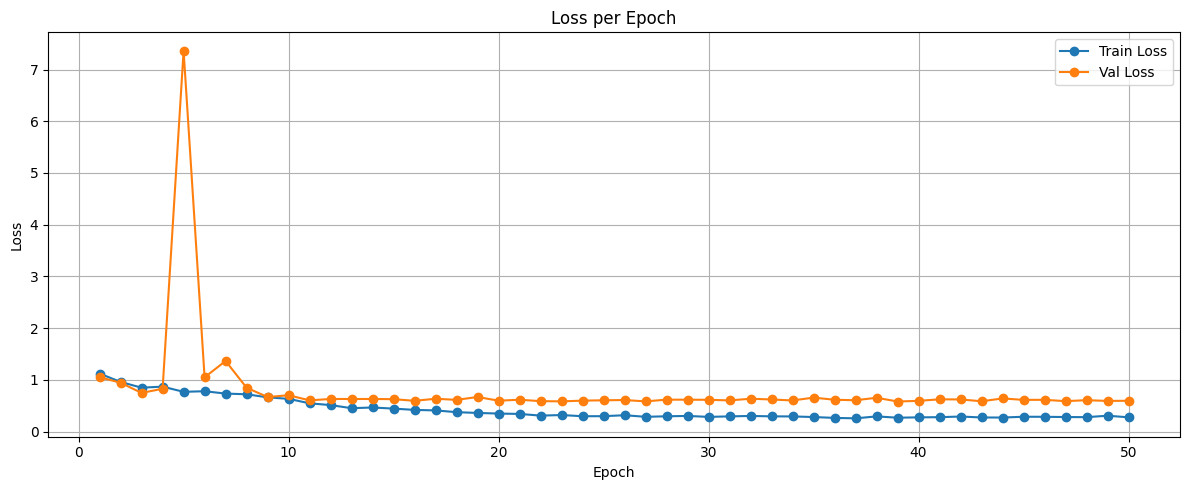

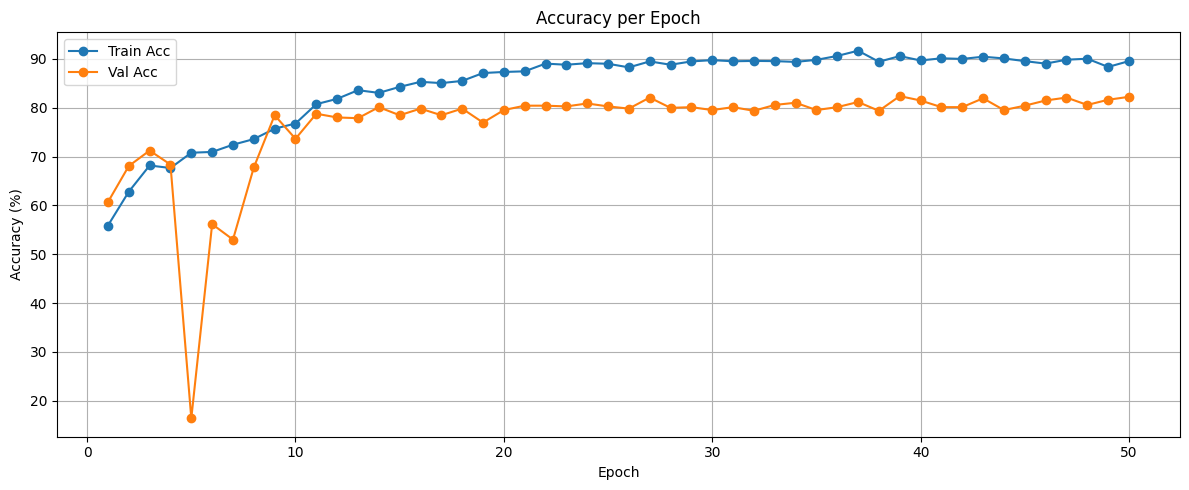

In [9]:
from utils.helper import load_logs, show_loss, extract_metrics_from_log, show_acc

log = load_logs('1st_train.txt')
train_loss, val_loss, train_acc, val_acc = extract_metrics_from_log(log)
show_loss(train_loss, val_loss)
show_acc(train_acc, val_acc)


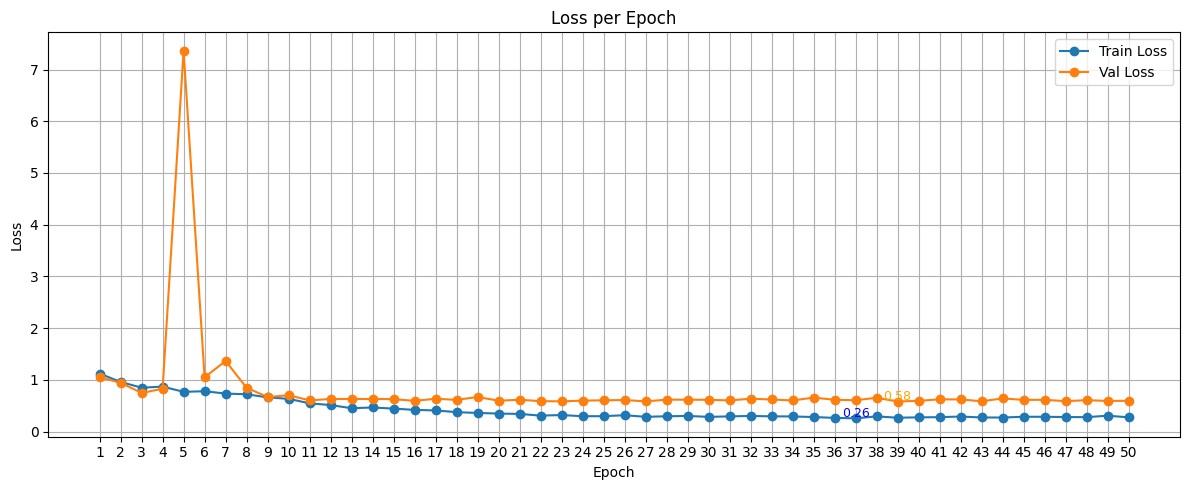

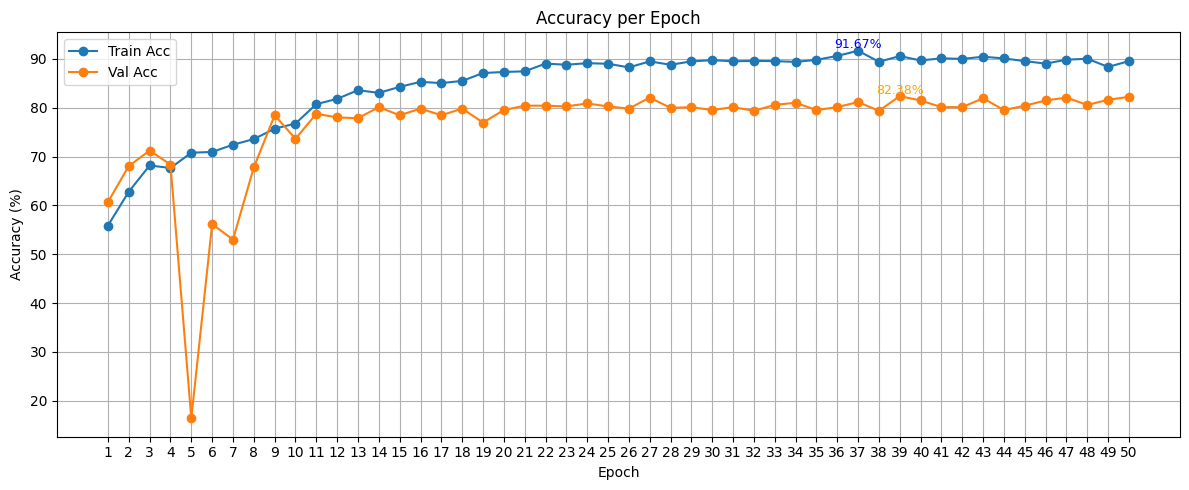

In [11]:
import torch
import os
import re
from utils.config import load_config

from matplotlib import pyplot as plt

epochs = list(range(1, 51))


def save_model(model, path):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    torch.save(model.state_dict(), path)
    print('model saved')


# def load_model(model, path):
def load_logs(file_name):
    log_dir = load_config()['output']['log_dir']
    with open(log_dir + "/" + file_name, 'r') as f:
        return f.read()


def extract_metrics_from_log(log_text):
    train_loss, val_loss = [], []
    train_acc, val_acc = [], []

    # Tìm tất cả các dòng chứa thông số
    lines = log_text.strip().split('\n')
    for line in lines:
        match = re.match(r"Train Loss: ([\d.]+)\|Train Acc: ([\d.]+)%", line)
        if match:
            train_loss.append(float(match.group(1)))
            train_acc.append(float(match.group(2)))
        else:
            match = re.match(r"Val Loss: ([\d.]+)\|Val Acc: ([\d.]+)%", line)
            if match:
                val_loss.append(float(match.group(1)))
                val_acc.append(float(match.group(2)))

    return [train_loss, val_loss, train_acc, val_acc]


def show_loss(train_loss, val_loss):
    plt.figure(figsize=(12, 5))
    plt.plot(epochs, train_loss, label='Train Loss', marker='o')
    plt.plot(epochs, val_loss, label='Val Loss', marker='o')

    # Hiển thị điểm cực đại (max)
    min_train = min(train_loss)
    min_val = min(val_loss)
    idx_train = train_loss.index(min_train)
    idx_val = val_loss.index(min_val)

    plt.text(epochs[idx_train], min_train + 0.02, f"{min_train:.2f}", ha='center', fontsize=9, color='blue')
    plt.text(epochs[idx_val], min_val + 0.02, f"{min_val:.2f}", ha='center', fontsize=9, color='orange')

    plt.title('Loss per Epoch')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.xticks(epochs)

    plt.tight_layout()
    plt.show()



def show_acc(train_acc, val_acc):
    plt.figure(figsize=(12, 5))
    plt.plot(epochs, train_acc, label='Train Acc', marker='o')
    plt.plot(epochs, val_acc, label='Val Acc', marker='o')

    # Hiển thị điểm cực đại (max)
    max_train = max(train_acc)
    max_val = max(val_acc)
    idx_train = train_acc.index(max_train)
    idx_val = val_acc.index(max_val)
    
    plt.text(epochs[idx_train], max_train + 0.5, f"{max_train:.2f}%", ha='center', fontsize=9, color='blue')
    plt.text(epochs[idx_val], max_val + 0.5, f"{max_val:.2f}%", ha='center', fontsize=9, color='orange')

    plt.title('Accuracy per Epoch')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid(True)
    plt.xticks(epochs)

    plt.tight_layout()
    plt.show()


log = load_logs('1st_train.txt')
train_loss, val_loss, train_acc, val_acc = extract_metrics_from_log(log)
show_loss(train_loss, val_loss)
show_acc(train_acc, val_acc)